In [64]:
import os
import random
import itertools
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, random_split, DataLoader, Subset, ConcatDataset
from PIL import Image
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score
import torch.nn.functional as F
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
%matplotlib inline

In [65]:
from time import time
import torchvision.transforms as transforms

In [66]:
from datetime import datetime

In [67]:
# DATA_DIR = 'E:/Dataset/NWPURESISC_45/'

# TRAIN_DIR = DATA_DIR + 'train'
# TEST_DIR = DATA_DIR + 'test'

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])




In [6]:
classes = os.listdir(TRAIN_DIR)
classes

NameError: name 'TRAIN_DIR' is not defined

In [ ]:
print('TRAIN')
for label in classes:
    files = os.listdir('{}/{}'.format(TRAIN_DIR, label))
    print('{} {} \t {}'.format(len(files), label, files[:3]))

print()
print('TEST')
for label in classes:
    files = os.listdir('{}/{}'.format(TEST_DIR, label))
    print('{} {} \t {}'.format(len(files), label, files[:3]))

In [68]:
import torchvision.transforms as T
def _my_normalization(x):
    return x + (0.01**0.5)*torch.randn(x.shape)


transform = T.Compose([
T.Pad(16), # Use 8 or 16 for 256 data
T.RandomRotation([-5,5]), # Start here, increas
T.Resize(64),
T.RandomCrop(64),
#T.ColorJitter(brightness=0.5,contrast=0.5, saturation=0.5),    
T.ToTensor(),
#T.Lambda(_my_normalization),
         
#T.Normalize(mean=[0.36801723, 0.3809769, 0.34357962], std=[0.20345809, 0.18542756, 0.18488906], inplace=False),
#T.NoiseInjection(p=0.5, mean=0, std=0.5), # Write a nn.Module that adds
# randn_like to data. Suggest giving it a weight. Forward is
# data = data if torch.rand(1) > self.p else data + self.weight * (self.mean + (self.std * torch.randn_like(data)))
])

# train_dataset = ImageFolder(TRAIN_DIR, transform=transform)
# test_dataset = ImageFolder(TEST_DIR, transform=transform)


print("Downloading/Preparing CIFAR-10…")
train_dataset = datasets.CIFAR10(root="../data", train=True,  download=True, transform=train_tf)
test_dataset   = datasets.CIFAR10(root="../data", train=False, download=True, transform=test_tf)

len(train_dataset), len(test_dataset)

Downloading/Preparing CIFAR-10…
Files already downloaded and verified
Files already downloaded and verified


(50000, 10000)

In [69]:
def show_sample(img, label):
    plt.title('Label: {}, ({})'.format(classes[label], label))
    plt.imshow(img.permute(1, 2, 0))

In [14]:
index = random.randrange(len(train_dataset))
show_sample(*train_dataset[index])

NameError: name 'classes' is not defined

In [8]:
index = random.randrange(len(train_dataset))
show_sample(*train_dataset[index])

NameError: name 'show_sample' is not defined

In [70]:
random_seed = 42
torch.manual_seed(random_seed)

In [71]:
train_subset = train_dataset
test_subset = test_dataset
len(train_subset), len(test_subset)

(50000, 10000)

In [72]:
val_size = int(len(test_subset) * 0.3)
test_size = len(test_subset) - val_size

test_subset, val_subset = random_split(test_subset, [test_size, val_size])
len(train_subset), len(val_subset), len(test_subset)

(50000, 3000, 7000)

In [73]:
batch_size=64

In [74]:
# train_dataloader = DataLoader(train_subset, batch_size, shuffle=True, pin_memory=True)
# val_dataloader = DataLoader(val_subset, batch_size,  pin_memory=True)
# test_dataloader = DataLoader(test_subset, batch_size, pin_memory=True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
test_dataloader   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
print(f"Data ready → train: {len(train_dataset)}, val: {len(test_dataset)}")

Data ready → train: 50000, val: 10000


In [75]:
def show_batch(dl, invert=False):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(16, 16))
        ax.set_xticks([]); ax.set_yticks([])
        data = 1-images if invert else images
        ax.imshow(make_grid(images[:32], nrow=8).permute(1, 2, 0))
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


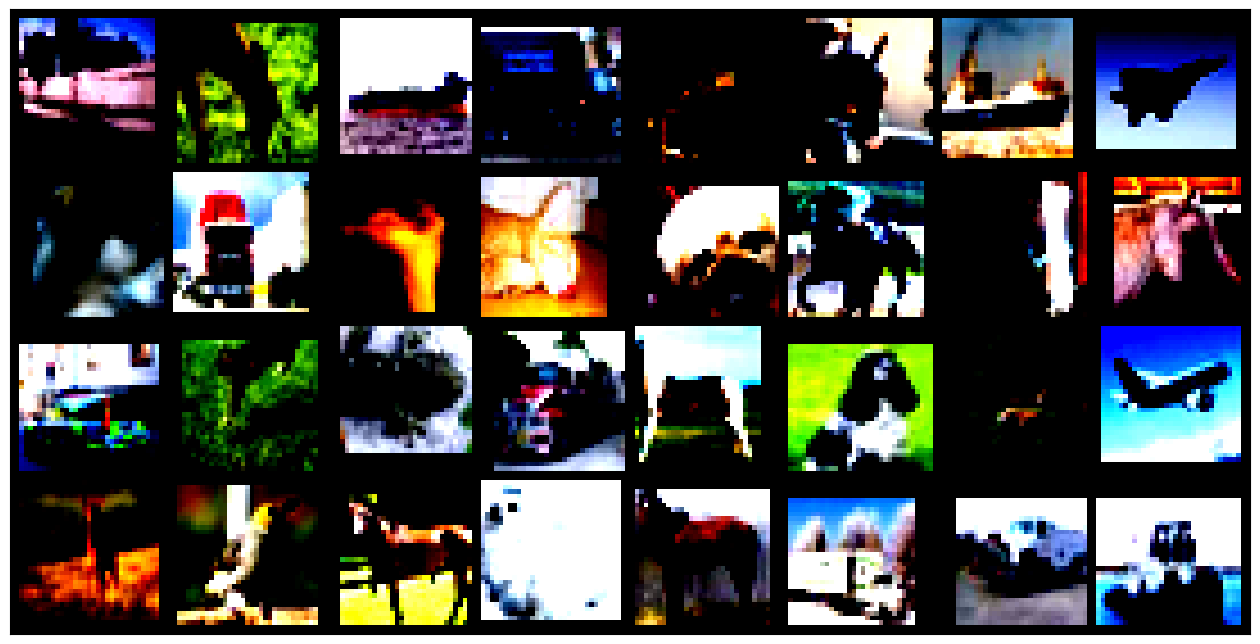

In [76]:
show_batch(train_dataloader)

In [77]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [78]:
# general imports
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch.nn.functional as F

In [79]:
# initialize device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name())
else:
    device = torch.device("cpu")
print(device)

NVIDIA GeForce RTX 2070 Super
cuda


In [85]:
# create model
from vision_lstm3 import VisionLSTM2

model = VisionLSTM2(
    dim=192,
    #dim=128,
    #input_shape=(3, 64, 64),
    input_shape=(3, 32, 32),
    patch_size=4,
    depth=2,
    #output_shape=(45,),
    output_shape=(10,),
    mode="classifier",
    pooling="bilateral_flatten",
    #drop_path_rate=0.1,
    drop_path_rate=0,
    drop_path_decay=True,
    stride=None,
    legacy_norm=False,
    conv_kind="2d",
    conv_kernel_size=3,
    proj_bias=True,
    norm_bias=True,
    feature_extractor_channels=[32, 64, 128, 192],  # Example channel sizes for each layer
    #feature_extractor_channels=[16, 32, 64, 128],  # Example channel sizes for each layer
    use_fourier=True  # Enable wavelet transform
).to(device)

In [86]:
from CosineScheduler import CosineScheduler
lr = 0.001

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.5)

nepochs = 50
warmup=5
linear_wi=True
scheduler = CosineScheduler(optimizer,total_epochs=nepochs,
                            warmup=warmup,
                            linear_wu=linear_wi)

In [87]:
import torch
from torch.cuda.amp import autocast, GradScaler
from time import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

scaler = GradScaler()  # Initialize the gradient scaler for mixed precision

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def Train(epoch, print_every=30):
    model.train()
    total_loss = 0
    start_time = time()
    
    accuracy = []
    
    for i, batch in enumerate(train_dataloader, 1):
        minput = batch[0]  # Get batch of images from our train dataloader
        target = batch[1]  # Get the corresponding target
        minput, target = minput.to(device), target.to(device)
        
        moutput = model(minput)  # output by our model
        
        loss = criterion(moutput, target)  # compute cross-entropy loss
        total_loss += loss.item()

        optimizer.zero_grad()  # Clear the gradients
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update Model parameters
        scheduler.step()
        
        argmax = moutput.argmax(dim=1)  # Get the class index with maximum probability predicted by the model
        accuracy.append((target == argmax).sum().item() / target.shape[0])  # calculate accuracy

        if i % print_every == 0:
            print(f'Epoch: [{epoch}/{num_epochs}], Step: [{i}/{len(train_dataloader)}], '
                  f'Train Loss: {loss.item():.4f}, Accuracy: {sum(accuracy)/len(accuracy):.2f}, '
                  f'Time: {time() - start_time:.2f} sec')
    
    avg_train_accuracy = sum(accuracy) / len(accuracy) if accuracy else 0
    return total_loss / len(train_dataloader), avg_train_accuracy  # Returning Average Training Loss and Accuracy

def Test(epoch):
    model.eval()
    total_loss = 0
    start_time = time()

    accuracy = []
    
    with torch.inference_mode():  # Disable gradient calculations
        #for i, batch in enumerate(val_dataloader):
        for i, batch in enumerate(test_dataloader):
            minput = batch[0]  # Get batch of images from our test dataloader
            target = batch[1]  # Get the corresponding target
            minput, target = minput.to(device), target.to(device)
            
            moutput = model(minput)  # output by our model

            loss = criterion(moutput, target)  # compute cross-entropy loss
            total_loss += loss.item()
            
            argmax = moutput.argmax(dim=1)  # Find the class with maximum score
            accuracy.append((target == argmax).sum().item() / target.shape[0])  # Calculate accuracy
            
    #avg_loss = total_loss / len(val_dataloader)
    avg_loss = total_loss / len(test_dataloader)
    avg_accuracy = sum(accuracy) / len(accuracy) if accuracy else 0
    
    print(f'Epoch: [{epoch}/{num_epochs}], Test Loss: {avg_loss:.4f}, '
          f'Accuracy: {avg_accuracy:.2f}, Time: {time() - start_time:.2f} sec')
    
    return avg_loss, avg_accuracy  # Returning Average Testing Loss and Accuracy

# Initialize variables for tracking the best model
best_loss = float('inf')
best_model_wts = None

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []



In [ ]:
start_time = datetime.now()

num_epochs = 20  # Set the number of epochs

for epoch in range(1, num_epochs + 1):
    train_loss, train_accuracy = Train(epoch, print_every=10)
    test_loss, test_accuracy = Test(epoch)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    
    # Check if the current model is the best so far
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_wts = model.state_dict()  # Save the best model's weights
    
    torch.cuda.empty_cache()  # Clear cached memory
    
    print('\n')

# Save the best model after all epochs are completed
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), 'VixLSTM_best_model_UCMerced.pth')
    print(f'Best model saved with loss: {best_loss:.4f}')

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


Epoch: [1/20], Step: [10/782], Train Loss: 2.3066, Accuracy: 0.10, Time: 30.48 sec
Epoch: [1/20], Step: [20/782], Train Loss: 2.3131, Accuracy: 0.11, Time: 33.31 sec
Epoch: [1/20], Step: [30/782], Train Loss: 2.2756, Accuracy: 0.12, Time: 36.15 sec
Epoch: [1/20], Step: [40/782], Train Loss: 2.2619, Accuracy: 0.14, Time: 39.00 sec
Epoch: [1/20], Step: [50/782], Train Loss: 2.2705, Accuracy: 0.15, Time: 41.83 sec
Epoch: [1/20], Step: [60/782], Train Loss: 2.2458, Accuracy: 0.15, Time: 44.67 sec
Epoch: [1/20], Step: [70/782], Train Loss: 2.2526, Accuracy: 0.16, Time: 47.50 sec
Epoch: [1/20], Step: [80/782], Train Loss: 2.2608, Accuracy: 0.17, Time: 50.32 sec
Epoch: [1/20], Step: [90/782], Train Loss: 2.2149, Accuracy: 0.17, Time: 53.16 sec
Epoch: [1/20], Step: [100/782], Train Loss: 2.2182, Accuracy: 0.18, Time: 56.00 sec
Epoch: [1/20], Step: [110/782], Train Loss: 2.1968, Accuracy: 0.19, Time: 58.85 sec
Epoch: [1/20], Step: [120/782], Train Loss: 2.1926, Accuracy: 0.19, Time: 61.69 sec
E

In [84]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                                  Output Shape              Param #
VisionLSTM2                                             [1, 10]                   --
├─FeatureExtractor: 1-1                                 [1, 195, 32, 32]          --
│    └─Sequential: 2-1                                  [1, 192, 32, 32]          --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           896
│    │    └─ReLU: 3-2                                   [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-3                                 [1, 64, 32, 32]           18,496
│    │    └─ReLU: 3-4                                   [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-5                                 [1, 128, 32, 32]          73,856
│    │    └─ReLU: 3-6                                   [1, 128, 32, 32]          --
│    │    └─Conv2d: 3-7                                 [1, 192, 32, 32]          221,376
│    │    └─ReLU: 3-8                         

In [41]:
@torch.no_grad()
def predictions(model, dataloader):
    torch.cuda.empty_cache()
    preds_list = torch.zeros(0, dtype=torch.long, device=device)
    labels_list = torch.zeros(0, dtype=torch.long, device=device)
    for i, batch in enumerate(dataloader):
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds  = torch.max(outputs, dim=1)
        preds_list = torch.cat((preds_list, preds), 0)
        labels_list = torch.cat((labels_list, labels), 0)
    return preds_list, labels_list

In [42]:
preds_list, labels_list = predictions(model, test_dataloader)

[test] Accuracy: 87.68%


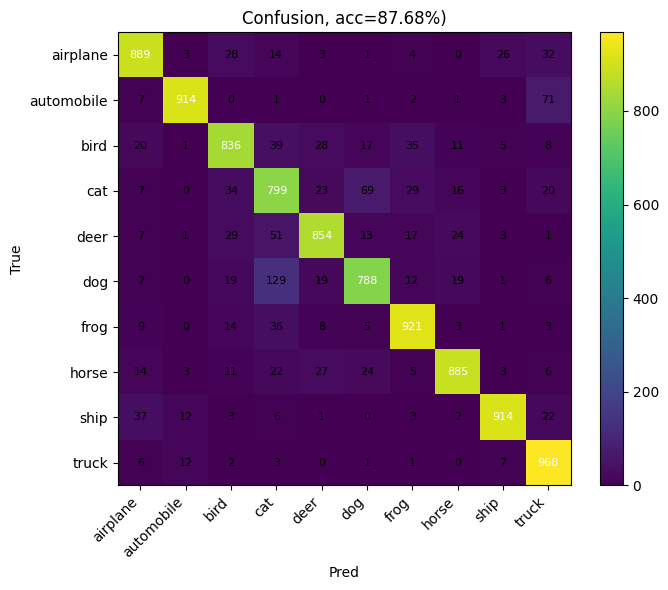


Classification Report:
               precision    recall  f1-score   support

    airplane       0.89      0.89      0.89      1000
  automobile       0.97      0.91      0.94      1000
        bird       0.86      0.84      0.85      1000
         cat       0.73      0.80      0.76      1000
        deer       0.89      0.85      0.87      1000
         dog       0.86      0.79      0.82      1000
        frog       0.90      0.92      0.91      1000
       horse       0.92      0.89      0.90      1000
        ship       0.95      0.91      0.93      1000
       truck       0.85      0.97      0.91      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

OA: 0.8768
AA: 0.8767999999999999
Kappa: 0.8631111111111112
              precision    recall  f1-score   support

    airplane     0.8863    0.8890    0.8877      1000
  automobile     0.9662    0.9140    0.9394    

In [52]:
from sklearn.metrics import classification_report,recall_score,cohen_kappa_score,accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from typing import List

def plot_confusion(cm: np.ndarray, classes: List[str], title="Confusion Matrix"):
    """画混淆矩阵（单图，无 seaborn）"""
    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes)
    ax.set_ylabel('True'); ax.set_xlabel('Pred')
    thr = cm.max() * 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i,j]
            ax.text(j, i, int(val), ha='center', va='center',
                    color='white' if val > thr else 'black', fontsize=8)
    fig.tight_layout()
    plt.show()
    
preds_list, labels_list = predictions(model, test_dataloader)
preds_list, labels_list

#SAVE_PATH='E:/Results/'
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
## classfication report
# test_pred = preds_list.cpu()
# test_true = labels_list.cpu()

y_pred = preds_list.cpu()
y_te = labels_list.cpu()

acc = accuracy_score(y_te, y_pred)
print(f"[test] Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_te, y_pred, labels=list(range(10)))
plot_confusion(cm, CLASSES, title=f"Confusion, acc={acc*100:.2f}%)")
print("\nClassification Report:\n", classification_report(y_te, y_pred, target_names=CLASSES))

# OA = accuracy_score(test_true,test_pred)
# AA = recall_score(test_true,test_pred,average='macro')
# kappa = cohen_kappa_score(test_true,test_pred)
# report_log = F"OA: {OA}\nAA: {AA}\nKappa: {kappa}\n"
# report_log += classification_report(test_true,test_pred,target_names=classes,digits=4)
#print(report_log)
# fp = open(os.path.join(SAVE_PATH,'ViCxLSTM_classfication_report_NWPURESISC_45.txt'),'w+')
# fp.writelines(report_log)
# fp.close()